# Classroom Air Quality Assessment and Automated Ventilation Prediction (Decision Tree - C5.0)

# Problem Statement

Indoor air quality plays a crucial role in maintaining a healthy and productive learning environment. Factors such as carbon dioxide (CO₂) concentration, particulate matter (PM2.5), temperature, humidity, student occupancy, and environmental conditions can significantly impact air quality within classrooms.

This project aims to develop a machine learning classification model that predicts the appropriate ventilation decision based on real-time indoor environmental measurements. The dataset contains information about classroom conditions, including CO₂ levels, PM2.5 concentration, temperature, humidity, student count, school period, and robot sensor positions.

By analyzing these factors, the model learns patterns associated with different ventilation actions and assists in making intelligent ventilation decisions to improve indoor air quality, enhance occupant comfort, and support a healthier classroom environment.

# Dataset Structure
- The dataset contains indoor air quality measurements collected in a school environment. It includes environmental parameters such as CO₂ concentration, PM2.5 levels, temperature, humidity, student occupancy, and robot location data. The goal is to analyze how these factors influence ventilation decisions and build a predictive classification model.
- Total Rows : [Enter Total Rows from your dataset]
- Total Columns : 10
- Independent Variables:
1. Timestamp
2. School Period
3. Student Count
4. CO₂ (ppm)
5. PM2.5 (µg/m³)
6. Temperature
7. Humidity
- Target Column : Ventilation Decision
- Problem Type : Classification Problem
- Model Used : C5.0 Classifier

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier   
from sklearn import tree
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style='darkgrid',palette='viridis')

# Dataset Loaded

In [2]:
df=pd.read_csv("air_quality-selected-columns.csv")
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE


# Data Understanding

In [3]:
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE


In [4]:
df.tail()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
495,2025-11-12 22:01:30,End of Day,4,501.6,6.26,20.2,41.8,0.0,0.0,IDLE
496,2025-11-12 22:03:12,End of Day,1,474.9,6.66,20.2,41.6,0.2,0.0,IDLE
497,2025-11-12 22:04:54,End of Day,0,454.7,6.26,20.2,41.5,0.5,0.1,IDLE
498,2025-11-12 22:06:36,End of Day,6,471.8,6.13,20.2,41.5,0.7,0.0,IDLE
499,2025-11-12 22:08:18,End of Day,9,488.6,5.85,20.2,41.6,1.1,0.0,IDLE


In [5]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:500
Number oF columns: 10


In [6]:
df.describe()

,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
std,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781
min,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000


In [7]:
df.describe(include=object)

,timestamp,school_period,ventilation_decision
count,500,500,500
unique,500,9,2
top,2025-11-12 08:00:00,End of Day,IDLE
freq,1,288,335


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   school_period            500 non-null    object 
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


In [9]:
df.dtypes

timestamp                   object
school_period               object
student_count_estimated      int64
co2_ppm                    float64
pm25_ugm3                  float64
temperature_c              float64
humidity_pct               float64
robot_x_pos                float64
robot_y_pos                float64
ventilation_decision        object
dtype: object

# Data Quality Check

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

timestamp                  0
school_period              0
student_count_estimated    0
co2_ppm                    0
pm25_ugm3                  0
temperature_c              0
humidity_pct               0
robot_x_pos                0
robot_y_pos                0
ventilation_decision       0
dtype: int64

# Exploratory Data Analysis

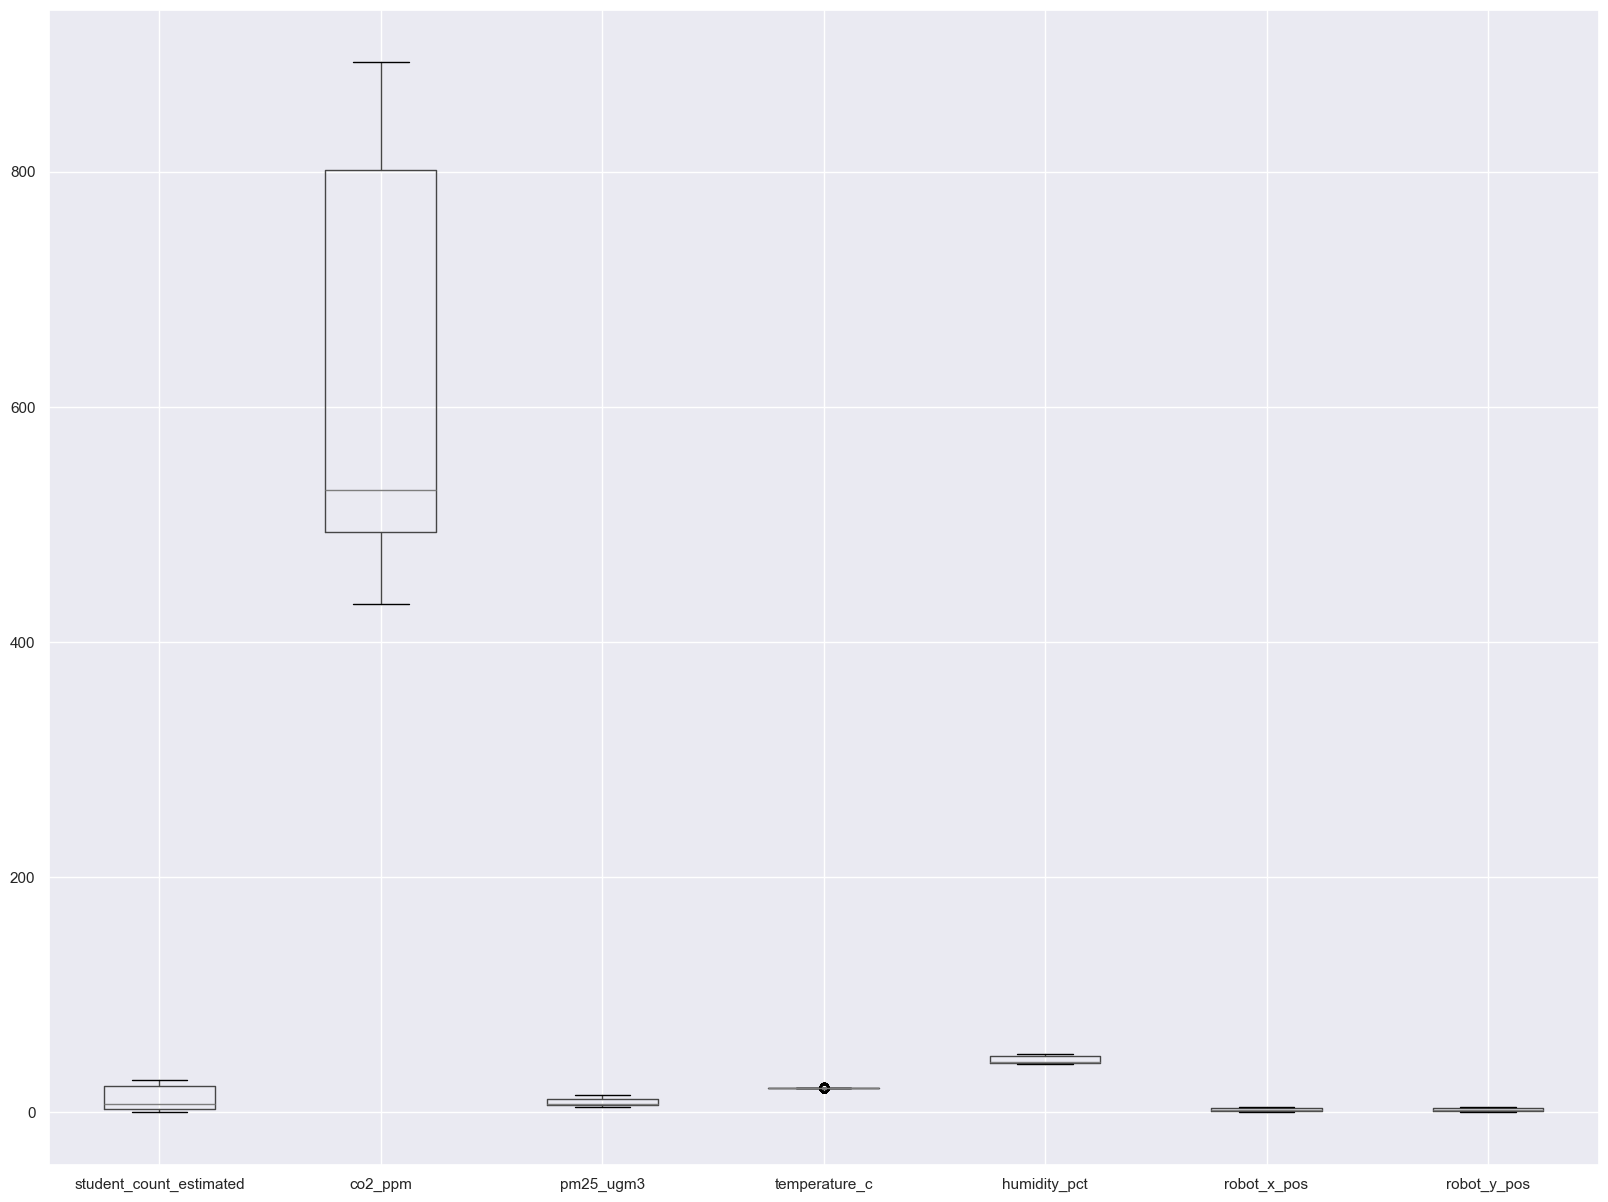

In [16]:
plt.figure(figsize=(20,15))
df.boxplot()
plt.show()

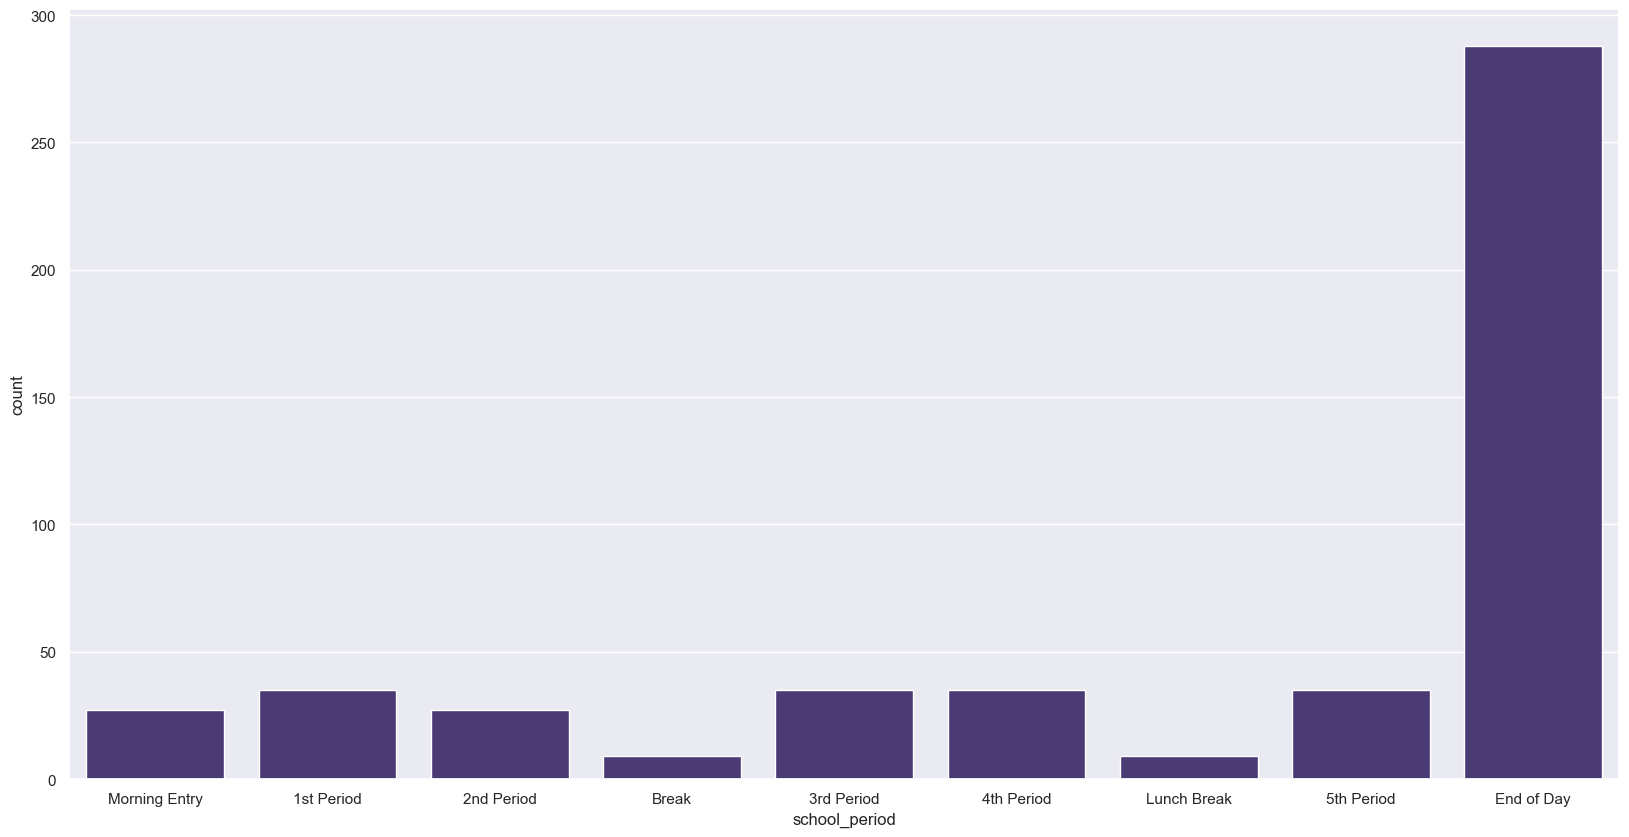

In [20]:
plt.figure(figsize=(20,10))
sns.countplot(x=df['school_period'],data=df)
plt.show()

In [26]:
df.groupby(["ventilation_decision","school_period"])["temperature_c"].mean().sort_values(ascending=True)

ventilation_decision  school_period
IDLE                  End of Day       20.374386
                      3rd Period       20.500000
                      5th Period       20.500000
                      Lunch Break      20.500000
MONITOR               3rd Period       20.500000
                      4th Period       20.500000
                      5th Period       20.500000
                      End of Day       20.500000
                      Lunch Break      20.500000
IDLE                  Break            20.633333
MONITOR               Break            20.766667
IDLE                  1st Period       20.800000
MONITOR               1st Period       20.800000
                      2nd Period       20.800000
IDLE                  Morning Entry    20.888889
Name: temperature_c, dtype: float64

In [27]:
df.groupby(["ventilation_decision","school_period"])["humidity_pct"].mean().sort_values(ascending=True)

ventilation_decision  school_period
IDLE                  End of Day       42.171579
                      Morning Entry    44.696296
                      1st Period       44.800000
                      3rd Period       46.760000
                      5th Period       46.800000
                      Break            47.150000
                      Lunch Break      47.300000
MONITOR               1st Period       47.417647
                      End of Day       47.533333
                      5th Period       47.680000
                      3rd Period       48.693333
                      Lunch Break      48.700000
                      Break            48.733333
                      2nd Period       49.088889
                      4th Period       49.385714
Name: humidity_pct, dtype: float64

# Encoding

In [28]:
df["school_period"].value_counts()

school_period
End of Day       288
1st Period        35
3rd Period        35
4th Period        35
5th Period        35
Morning Entry     27
2nd Period        27
Break              9
Lunch Break        9
Name: count, dtype: int64

In [29]:
# Ordinal Encoding
period_mapping = {
    'Morning Entry': 0,
    '1st Period': 1,
    '2nd Period': 2,
    'Break': 3,
    '3rd Period': 4,
    'Lunch Break': 5,
    '4th Period': 6,
    '5th Period': 7,
    'End of Day': 8
}

df['school_period'] = df['school_period'].map(period_mapping)

In [30]:
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,2025-11-12 08:00:00,0,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE
1,2025-11-12 08:01:42,0,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE
2,2025-11-12 08:03:24,0,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE
3,2025-11-12 08:05:06,0,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE
4,2025-11-12 08:06:48,0,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE


# Droping Unnecessary Column

In [33]:
df.drop(columns="timestamp",inplace=True)

In [34]:
df.head()

,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,0,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE
1,0,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE
2,0,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE
3,0,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE
4,0,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE


# Defining X and y

In [35]:
X=df.drop(columns='ventilation_decision')
y=df["ventilation_decision"]

# Train-Test Split

In [36]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

# Model Building

In [39]:
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Prediction

In [41]:
y_pred=dt.predict(x_test)
y_pred

array(['IDLE', 'MONITOR', 'IDLE', 'MONITOR', 'MONITOR', 'IDLE', 'IDLE',
       'MONITOR', 'MONITOR', 'IDLE', 'IDLE', 'MONITOR', 'IDLE', 'MONITOR',
       'IDLE', 'IDLE', 'IDLE', 'MONITOR', 'IDLE', 'IDLE', 'IDLE', 'IDLE',
       'IDLE', 'IDLE', 'MONITOR', 'IDLE', 'IDLE', 'MONITOR', 'IDLE',
       'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE',
       'MONITOR', 'MONITOR', 'MONITOR', 'IDLE', 'IDLE', 'IDLE', 'MONITOR',
       'MONITOR', 'MONITOR', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'MONITOR',
       'MONITOR', 'MONITOR', 'IDLE', 'MONITOR', 'MONITOR', 'MONITOR',
       'IDLE', 'MONITOR', 'MONITOR', 'IDLE', 'IDLE', 'IDLE', 'IDLE',
       'MONITOR', 'MONITOR', 'IDLE', 'MONITOR', 'IDLE', 'IDLE', 'IDLE',
       'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'MONITOR', 'IDLE',
       'IDLE', 'MONITOR', 'MONITOR', 'IDLE', 'IDLE', 'IDLE', 'MONITOR',
       'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE', 'IDLE',
       'IDLE', 'IDLE', 'MONITOR', 'MONITOR', 'IDLE', 'IDLE', 'ID

# Evaluation

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        IDLE       1.00      1.00      1.00        86
     MONITOR       1.00      1.00      1.00        39

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



In [43]:
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  1.0
Testing Accuracy:  1.0


# Conclusion

The machine learning model achieved 100% training accuracy and 100% testing accuracy, indicating that it correctly classified all instances in both the training and testing datasets. The identical performance on both datasets suggests that the model generalized exceptionally well to unseen data without showing signs of overfitting or underfitting.

Such perfect accuracy indicates that the features in the dataset are highly informative and allow clear separation between the target classes. Therefore, the developed model can be considered highly effective for predicting ventilation decisions based on air quality and environmental parameters.